# UAV Fault Prediction Using Time-Series Machine Learning

## Abstract

This project focuses on **UAV fault detection and early fault prediction** using time-series flight telemetry data. The data includes control commands, measured states, velocity, IMU, and airspeed features collected from multiple UAV flights.

The data is chronologically processed, relevant features are selected, and features are standardized for model training. `binary_fault` represents the current fault state, while `fault_onset` identifies the transition from normal operation to a fault.

Three approaches will be evaluated: **XGBoost** as a baseline, **anomaly detection** for identifying abnormal pre-fault behavior, and **Liquid Neural Networks (LNN)** for learning temporal patterns. The final goal is to determine whether UAV faults can be **predicted before their onset**.

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, precision_recall_curve, auc,fbeta_score,precision_score, recall_score

In [34]:
df_train = pd.read_csv("../data/train_raw.csv")

# Dataset Size

In [35]:
df = df_train.copy()

print("Original shape:", df.shape)
print("columans : ")
df.columns

Original shape: (132937, 24)
columans : 


Index(['bag', 'timestamp_ns', 'airspeed_cmd', 'airspeed_meas',
       'airspeed_error', 'roll_cmd', 'roll_meas', 'roll_error', 'pitch_cmd',
       'pitch_meas', 'pitch_error', 'yaw_cmd', 'yaw_meas', 'yaw_error',
       'vel_x', 'vel_y', 'vel_z', 'imu_x', 'imu_y', 'imu_z', 'engine_fault',
       'aileron_fault', 'elevator_fault', 'rudder_fault'],
      dtype='object')

In [36]:
df.dtypes

bag                object
timestamp_ns        int64
airspeed_cmd      float64
airspeed_meas     float64
airspeed_error    float64
roll_cmd          float64
roll_meas         float64
roll_error        float64
pitch_cmd         float64
pitch_meas        float64
pitch_error       float64
yaw_cmd           float64
yaw_meas          float64
yaw_error         float64
vel_x             float64
vel_y             float64
vel_z             float64
imu_x             float64
imu_y             float64
imu_z             float64
engine_fault        int64
aileron_fault       int64
elevator_fault      int64
rudder_fault        int64
dtype: object

# Correlaion of Data

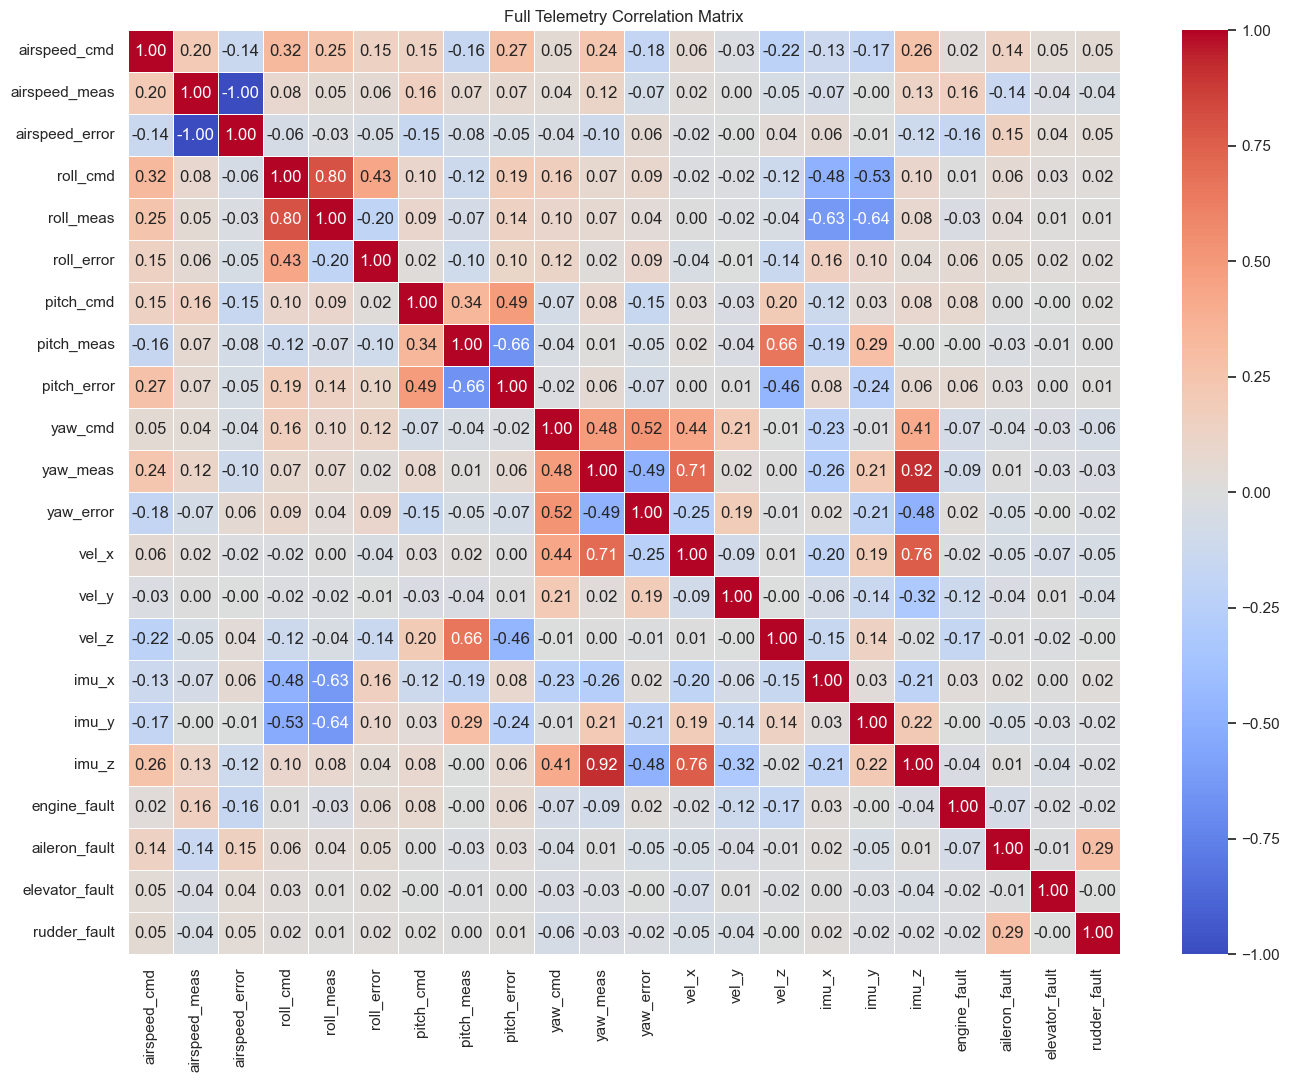

In [37]:
numerical_cols = df.drop(columns=['bag', 'timestamp_ns'], errors='ignore')
corr_matrix = numerical_cols.corr()

# 2. Plot the comprehensive heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, linewidths=0.5)
plt.title("Full Telemetry Correlation Matrix")
plt.show()

# Summary of Dataset

In [38]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
timestamp_ns,132937.0,1.536055e+18,2.790122e+15,1.531944e+18,1.532985e+18,1.536693e+18,1.538765e+18,1.539876e+18
airspeed_cmd,132937.0,1.562505e+01,4.834310e-01,1.500000e+01,1.500000e+01,1.600000e+01,1.600000e+01,1.600000e+01
airspeed_meas,132937.0,4.893964e+00,7.405477e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.448553e+01,2.648424e+01
airspeed_error,132937.0,1.073109e+01,7.322463e+00,-1.133438e+01,1.420175e+00,1.500000e+01,1.600000e+01,1.600000e+01
roll_cmd,132937.0,4.774754e+00,2.023759e+01,-4.500000e+01,-2.340000e+00,1.170000e+00,1.375000e+01,4.499000e+01
roll_meas,132937.0,6.370051e+00,1.865174e+01,-6.645238e+01,-1.124623e+00,2.366713e+00,1.384934e+01,7.128139e+01
roll_error,132937.0,-1.595298e+00,1.245943e+01,-1.062053e+02,-5.706806e+00,-8.780489e-01,3.903264e+00,9.828865e+01
pitch_cmd,132914.0,-6.528449e-01,5.751668e+00,-2.499000e+01,-3.690000e+00,-4.200000e-01,1.910000e+00,2.000000e+01
pitch_meas,132914.0,6.437144e-01,6.690156e+00,-5.688078e+01,-1.615566e+00,5.730504e-01,2.629524e+00,7.293653e+01
pitch_error,132914.0,-1.296559e+00,7.204381e+00,-9.304937e+01,-4.185391e+00,-1.114845e+00,1.695808e+00,5.941078e+01


## Critical Data Quality Issues Found in Raw Data
# Missing Values (NaNs):
- timestamp_ns & airspeed_*:132937 rows (Complete).
- pitch_*: 132937  rows (23 missing values).
- yaw_*: 132937  rows (21 missing values).
- vel_x, vel_y, vel_z: 172,480 rows (8,318 missing values missing!).
# Raw yaw_error Discontinuity:
- Min: -358.79, Max: +358.99.
- Observation: Raw yaw_error spans nearly $\pm 360^\circ$ due to standard $\pm 180^\circ$ compass wrap-around leaps. Angle wrapping to $[-180^\circ, +180^\circ]$ is mandatory.
# Feature Scaling
-  UAV features have very different numerical ranges which can be affect in modeling .



# Sort chronologically(Time series)

In [39]:
df = df.sort_values(
    by=["bag", "timestamp_ns"]
).reset_index(drop=True)

print(df[["bag", "timestamp_ns"]].head())

                               bag         timestamp_ns
0  carbonZ_2018-07-18-15-53-31.bag  1531943612183833069
1  carbonZ_2018-07-18-15-53-31.bag  1531943612184097830
2  carbonZ_2018-07-18-15-53-31.bag  1531943612184574457
3  carbonZ_2018-07-18-15-53-31.bag  1531943612214173518
4  carbonZ_2018-07-18-15-53-31.bag  1531943612255185463


# Identify individual flights
It allows me to keep different flights separate.

In [40]:
gap_ns_threshold = 1000 * 1e9  # 1000 seconds

df["time_gap_ns"] = (
    df.groupby("bag", sort=False)["timestamp_ns"]
      .diff()
)

bag_changed = df["bag"] != df["bag"].shift(1)

large_gap = df["time_gap_ns"] > gap_ns_threshold

df["flight_id"] = (
    bag_changed | large_gap
).cumsum() - 1

df.drop(columns=["time_gap_ns"], inplace=True)

print("Number of flights:", df["flight_id"].nunique())
print(df["flight_id"].value_counts().sort_index())

Number of flights: 30
flight_id
0      7760
1      2474
2      4029
3      2894
4      2798
5     11076
6       977
7      2771
8      2878
9      3603
10     2385
11     3603
12     1320
13      966
14     3699
15     6481
16     5185
17     3293
18    10639
19     5721
20     6283
21    14494
22     6499
23     4665
24     1866
25     2591
26     2667
27     5190
28     2622
29     1508
Name: count, dtype: int64


# Create flight-relative time
Absolute ROS timestamps aren't useful for comparing flights. That's why I change relative time for 
- identifying fault onset
- creating future targets
- creating time windows
- plotting behavior before faults

In [41]:
df["flight_time_sec"] = (
    df.groupby("flight_id", sort=False)["timestamp_ns"]
      .transform(
          lambda x: (x - x.min()) / 1e9
      )
)

df[
    ["flight_id", "flight_time_sec"]
].head(10)

,flight_id,flight_time_sec
0,0,0.000000
1,0,0.000265
2,0,0.000741
3,0,0.030340
4,0,0.071352
5,0,0.159289
6,0,0.193384
7,0,0.241772
8,0,0.275060
9,0,0.342245


# Fill missing value
Used Forward fill and backward fill because data is timeseries.

In [42]:
fill_cols = [c for c in ['vel_x', 'vel_y', 'vel_z', 'pitch_cmd', 'pitch_meas', 'pitch_error', 'yaw_cmd', 'yaw_meas', 'yaw_error'] if c in df.columns]
df[fill_cols] = df.groupby('flight_id', sort=False)[fill_cols].ffill().bfill()

# Correct the yaw error
Yaw is circular.
For example:

Command = 179°
Measured = -179°

The ordinary difference is: 358°
but physically the UAV is only about 2° away.

The wrapped version correctly represents the circular difference.

In [43]:
df["yaw_error_clean"] = (
    (df["yaw_error"] + 180) % 360
) - 180


# Added new Feature called Ground speed 
Instead of looking at three velocity components separately, this gives us the overall magnitude of the UAV's velocity.
Ground speed was derived from the three-dimensional velocity components to represent the overall magnitude of UAV motion. While vel_x, vel_y, and vel_z capture directional movement, ground_speed provides a compact measure of overall flight dynamics. This feature may help identify changes in UAV motion associated with developing faults.

In [44]:
df["ground_speed"] = np.sqrt(
    df["vel_x"]**2 +
    df["vel_y"]**2 +
    df["vel_z"]**2
)

df["ground_speed"].describe()

count    132937.000000
mean         15.215076
std           7.197670
min           0.010152
25%          13.928278
50%          16.871769
75%          19.541066
max          31.503337
Name: ground_speed, dtype: float64

# Class Imbalance 
Class are imbalance so combine all fault type into binary type . It will be also important for finding transition before fault happen for another approach.

In [45]:
fault_cols = ['engine_fault', 'aileron_fault', 'elevator_fault', 'rudder_fault']
present_faults = [c for c in fault_cols if c in df.columns]
if present_faults:
    df['binary_fault'] = (df[present_faults] > 0).any(axis=1).astype(int)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_21892\4159042800.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(


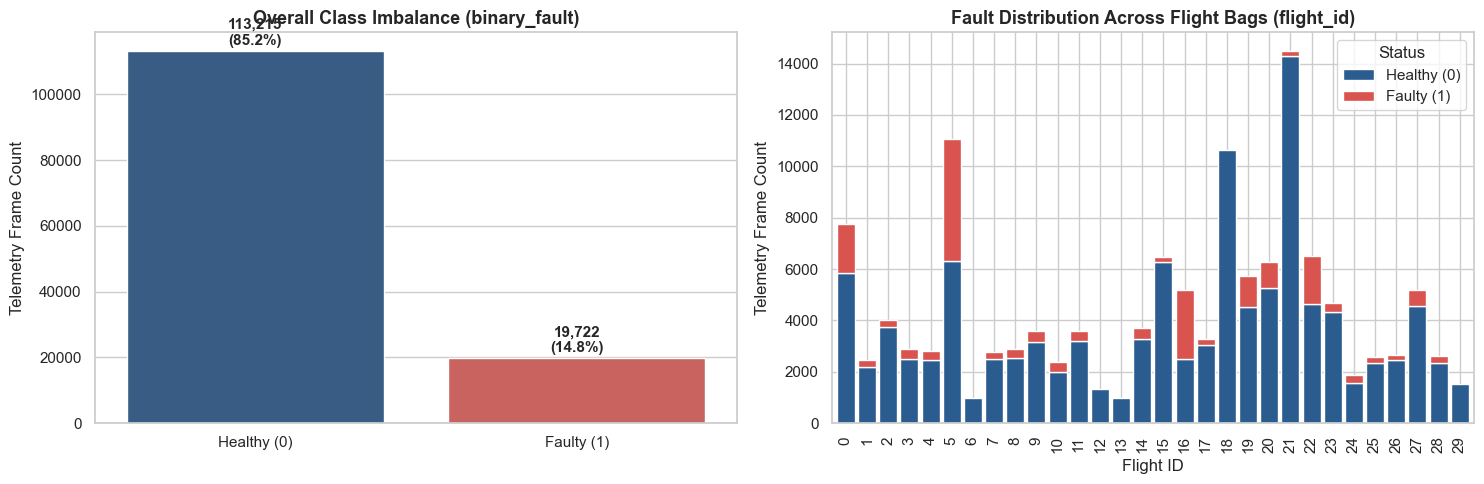

In [46]:
# Set visual style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Global Class Imbalance Bar Plot
fault_counts = df['binary_fault'].value_counts().sort_index()
percentages = df['binary_fault'].value_counts(normalize=True).sort_index() * 100

bars = sns.barplot(
    x=['Healthy (0)', 'Faulty (1)'], 
    y=fault_counts.values, 
    ax=axes[0], 
    palette=['#2b5c8f', '#d9534f']
)
axes[0].set_title('Overall Class Imbalance (binary_fault)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Telemetry Frame Count')

# Label bar counts and percentages
for i, count in enumerate(fault_counts.values):
    pct = percentages.values[i]
    axes[0].text(i, count + 1800, f'{count:,}\n({pct:.1f}%)', ha='center', fontsize=11, fontweight='bold')

# 2. Per-Flight Fault Distribution (Stacked Bar)
flight_faults = df.groupby(['flight_id', 'binary_fault']).size().unstack(fill_value=0)
flight_faults.plot(
    kind='bar', 
    stacked=True, 
    ax=axes[1], 
    color=['#2b5c8f', '#d9534f'], 
    width=0.85
)
axes[1].set_title('Fault Distribution Across Flight Bags (flight_id)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Flight ID')
axes[1].set_ylabel('Telemetry Frame Count')
axes[1].legend(['Healthy (0)', 'Faulty (1)'], title='Status', frameon=True)
axes[1].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

# Remove columns that are not need

In [47]:
cols_to_drop = [
    "timestamp_ns",
    "bag",
    "yaw_error",
    "engine_fault",
    "aileron_fault",
    "elevator_fault",
    "rudder_fault"
]

df = df.drop(
    columns=[
        c for c in cols_to_drop
        if c in df.columns
    ],
    errors="ignore"
)

print("Current shape:", df.shape)

Current shape: (132937, 22)


# Create Fault_onset
binary_fault describes the current fault state:

0 = normal ,
1 = currently faulty

However, for predictive modeling, we need to identify the exact moment when the system changes from normal to faulty.



By checking the start and end of each fault interval

- when a fault begins,
- how long the fault remains active,
- whether a flight contains multiple fault periods,
- whether any fault starts at the beginning of the recording.

This is important because goal is not simply to detect whether the UAV is currently faulty. I want to understand the behavior before a fault occurs.

In [48]:
# Calculate fault intervals
intervals = []

for flight_id, group in df.groupby("flight_id"):
    
    group = group.sort_values("flight_time_sec")
    
    fault_start = None
    
    for _, row in group.iterrows():
        
        if row["binary_fault"] == 1 and fault_start is None:
            fault_start = row["flight_time_sec"]
            
        elif row["binary_fault"] == 0 and fault_start is not None:
            fault_end = row["flight_time_sec"]
            
            intervals.append({
                "flight_id": flight_id,
                "fault_start": fault_start,
                "fault_end": fault_end,
                "duration_sec": fault_end - fault_start
            })
            
            fault_start = None

intervals_df = pd.DataFrame(intervals)

intervals_df

,flight_id,fault_start,fault_end,duration_sec
0,0,314.986822,356.308923,41.322102
1,5,0.000000,474.809016,474.809016
2,5,962.539142,1051.033837,88.494695
3,5,1181.753807,1237.156000,55.402193
4,14,115.097247,178.789042,63.691795
5,15,400.193820,442.886674,42.692855
6,16,116.333558,310.004298,193.670740
7,17,154.043161,195.097552,41.054391
8,19,188.193003,242.035303,53.842300
9,20,538.130770,586.950424,48.819654


- Using binary_fault alone would mainly teach a model to recognize an already-existing fault.

- Using fault_onset allows us to investigate whether the sensor patterns before the onset contain information that can be used for early fault prediction.

In [49]:
df = df.sort_values(
    ["flight_id", "flight_time_sec"]
).reset_index(drop=True)

df["fault_onset"] = (
    (df["binary_fault"] == 1) &
    (
        df.groupby("flight_id")["binary_fault"]
          .shift(1)
          .fillna(0)
          .eq(0)
    )
).astype(int)

print(df["fault_onset"].value_counts())

fault_onset
0    132904
1        33
Name: count, dtype: int64


In [50]:
print("Shape :",df.shape)
df.describe().T

Shape : (132937, 23)


,count,mean,std,min,25%,50%,75%,max
airspeed_cmd,132937.0,15.625053,0.483431,15.000000,15.000000,16.000000,16.000000,16.000000
airspeed_meas,132937.0,4.893964,7.405477,0.000000,0.000000,0.000000,14.485530,26.484240
airspeed_error,132937.0,10.731088,7.322463,-11.334381,1.420175,15.000000,16.000000,16.000000
roll_cmd,132937.0,4.774754,20.237594,-45.000000,-2.340000,1.170000,13.750000,44.989998
roll_meas,132937.0,6.370051,18.651736,-66.452385,-1.124623,2.366713,13.849339,71.281387
roll_error,132937.0,-1.595298,12.459434,-106.205280,-5.706806,-0.878049,3.903264,98.288647
pitch_cmd,132937.0,-0.652871,5.751217,-24.990000,-3.690000,-0.420000,1.910000,20.000000
pitch_meas,132937.0,0.643736,6.689591,-56.880775,-1.612970,0.573268,2.628115,72.936531
pitch_error,132937.0,-1.296607,7.203785,-93.049374,-4.185391,-1.114845,1.695190,59.410775
yaw_cmd,132937.0,-13.831289,99.545602,-179.000000,-88.000000,0.000000,89.000000,180.000000


# Normalization and Outlier 
I do  not automatically remove outliers because an extreme value may be the actual signal of a developing fault, not a bad data point.

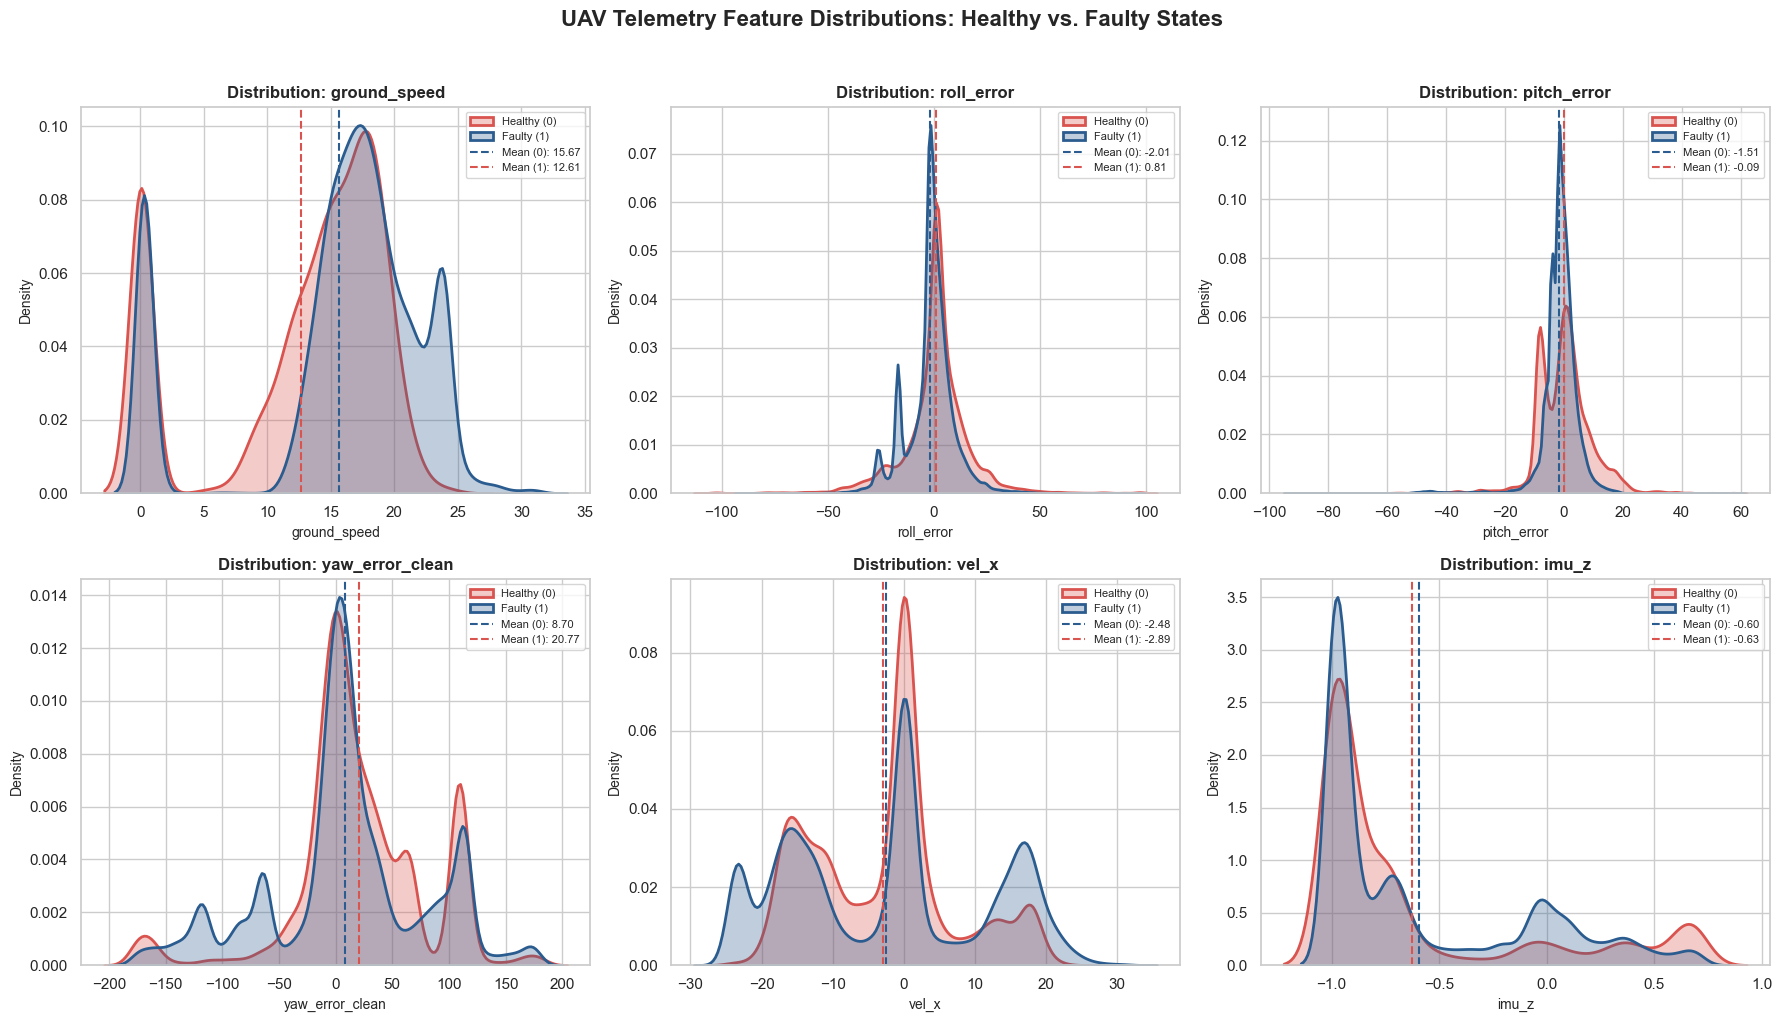

In [51]:
# Set visual style
sns.set_theme(style="whitegrid")

# Select core features to inspect distribution shifts
plot_features = [
    'ground_speed', 
    'roll_error', 
    'pitch_error', 
    'yaw_error_clean',
    'vel_x', 
    'imu_z'
]

# Create subplots grid
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, feature in enumerate(plot_features):
    ax = axes[idx]
    
    # Kernel Density Estimation (KDE) plot grouped by binary_fault
    sns.kdeplot(
        data=df,
        x=feature,
        hue='binary_fault',
        common_norm=False,
        palette={0: '#2b5c8f', 1: '#d9534f'},
        fill=True,
        alpha=0.3,
        linewidth=2,
        ax=ax
    )
    
    # Calculate means per class for reference lines
    mean_0 = df[df['binary_fault'] == 0][feature].mean()
    mean_1 = df[df['binary_fault'] == 1][feature].mean()
    
    ax.axvline(mean_0, color='#2b5c8f', linestyle='--', linewidth=1.5, label=f'Healthy Mean: {mean_0:.2f}')
    ax.axvline(mean_1, color='#d9534f', linestyle='--', linewidth=1.5, label=f'Faulty Mean: {mean_1:.2f}')
    
    ax.set_title(f'Distribution: {feature}', fontsize=12, fontweight='bold')
    ax.set_xlabel(feature, fontsize=10)
    ax.set_ylabel('Density', fontsize=10)
    ax.legend(['Healthy (0)', 'Faulty (1)', f'Mean (0): {mean_0:.2f}', f'Mean (1): {mean_1:.2f}'], fontsize=8)

plt.suptitle('UAV Telemetry Feature Distributions: Healthy vs. Faulty States', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Feature scaling 
Feature scaling is applied because the sensor and control variables have very different numerical ranges.
I used StandScaler as basedline

In [52]:
features = [
    'airspeed_cmd', 'airspeed_meas', 'airspeed_error',
    'roll_cmd', 'roll_meas', 'roll_error',
    'pitch_cmd', 'pitch_meas', 'pitch_error',
    'yaw_cmd', 'yaw_meas', 'yaw_error_clean',
    'vel_x', 'vel_y', 'vel_z',
    'imu_x', 'imu_y', 'imu_z',
    'ground_speed'
]

unique_flights = df['flight_id'].unique()
np.random.seed(42)
val_flights = np.random.choice(unique_flights, size=int(len(unique_flights) * 0.2), replace=False)

train_mask = ~df['flight_id'].isin(val_flights)
val_mask = df['flight_id'].isin(val_flights)

# 3. Raw Feature Matrices
X_train_raw = df.loc[train_mask, features].copy()
X_val_raw = df.loc[val_mask, features].copy()

# 4. Leak-Free Scaling (Fit strictly on Train, Transform both)
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_raw)
X_val_scaled = scaler.transform(X_val_raw)

# 5. Create DataFrame versions (Preserves column names and original indices)
df_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=features,
    index=X_train_raw.index
)

df_val_scaled = pd.DataFrame(
    X_val_scaled,
    columns=features,
    index=X_val_raw.index
)

# 6. Target and Metadata Alignments
y_train = df.loc[train_mask, 'binary_fault'].copy()
y_val = df.loc[val_mask, 'binary_fault'].copy()

flight_id_train = df.loc[train_mask, 'flight_id'].copy()
flight_id_val = df.loc[val_mask, 'flight_id'].copy()

# 7. Verification Summary
print(f"Train Scaled Shape: {df_train_scaled.shape} | Targets: {y_train.shape}")
print(f"Val Scaled Shape:   {df_val_scaled.shape}   | Targets: {y_val.shape}")
print(f"Train Flights ({len(np.unique(flight_id_train))}): {np.unique(flight_id_train)}")
print(f"Val Flights   ({len(np.unique(flight_id_val))}): {np.unique(flight_id_val)}")

Train Scaled Shape: (106827, 19) | Targets: (106827,)
Val Scaled Shape:   (26110, 19)   | Targets: (26110,)
Train Flights (24): [ 0  1  2  3  4  5  6  7 10 11 12 13 14 16 18 19 20 21 22 24 25 26 28 29]
Val Flights   (6): [ 8  9 15 17 23 27]


In [53]:
df_train_scaled.describe().T

,count,mean,std,min,25%,50%,75%,max
airspeed_cmd,106827.0,-4.475022e-16,1.000005,-1.236242,-1.236242,0.811047,0.811047,0.811047
airspeed_meas,106827.0,-5.853180e-18,1.000005,-0.685688,-0.685688,-0.685688,1.298055,2.868550
airspeed_error,106827.0,5.374283e-17,1.000005,-2.971739,-1.273935,0.613374,0.749512,0.749512
roll_cmd,106827.0,-4.576122e-17,1.000005,-2.453030,-0.374109,-0.190733,0.451825,1.994952
roll_meas,106827.0,-4.256858e-18,1.000005,-3.857114,-0.415388,-0.225216,0.393791,3.526984
roll_error,106827.0,-1.303663e-17,1.000005,-8.289502,-0.358517,0.065641,0.451244,7.957704
pitch_cmd,106827.0,-9.577930e-18,1.000005,-4.261828,-0.486294,0.066521,0.444947,3.583959
pitch_meas,106827.0,9.311876e-18,1.000005,-8.354849,-0.327325,-0.038500,0.294280,10.132632
pitch_error,106827.0,6.385287e-18,1.000005,-12.642014,-0.382669,0.029800,0.412377,8.386038
yaw_cmd,106827.0,1.569716e-17,1.000005,-1.622571,-0.704411,0.203546,0.887065,2.039865


In [54]:
# Train Splits
y_fault_train     = df.loc[train_mask, "binary_fault"].copy()
y_onset_train     = df.loc[train_mask, "fault_onset"].copy()
flight_id_train   = df.loc[train_mask, "flight_id"].copy()
flight_time_train = df.loc[train_mask, "flight_time_sec"].copy()

# Validation Splits
y_fault_val     = df.loc[val_mask, "binary_fault"].copy()
y_onset_val     = df.loc[val_mask, "fault_onset"].copy()
flight_id_val   = df.loc[val_mask, "flight_id"].copy()
flight_time_val = df.loc[val_mask, "flight_time_sec"].copy()

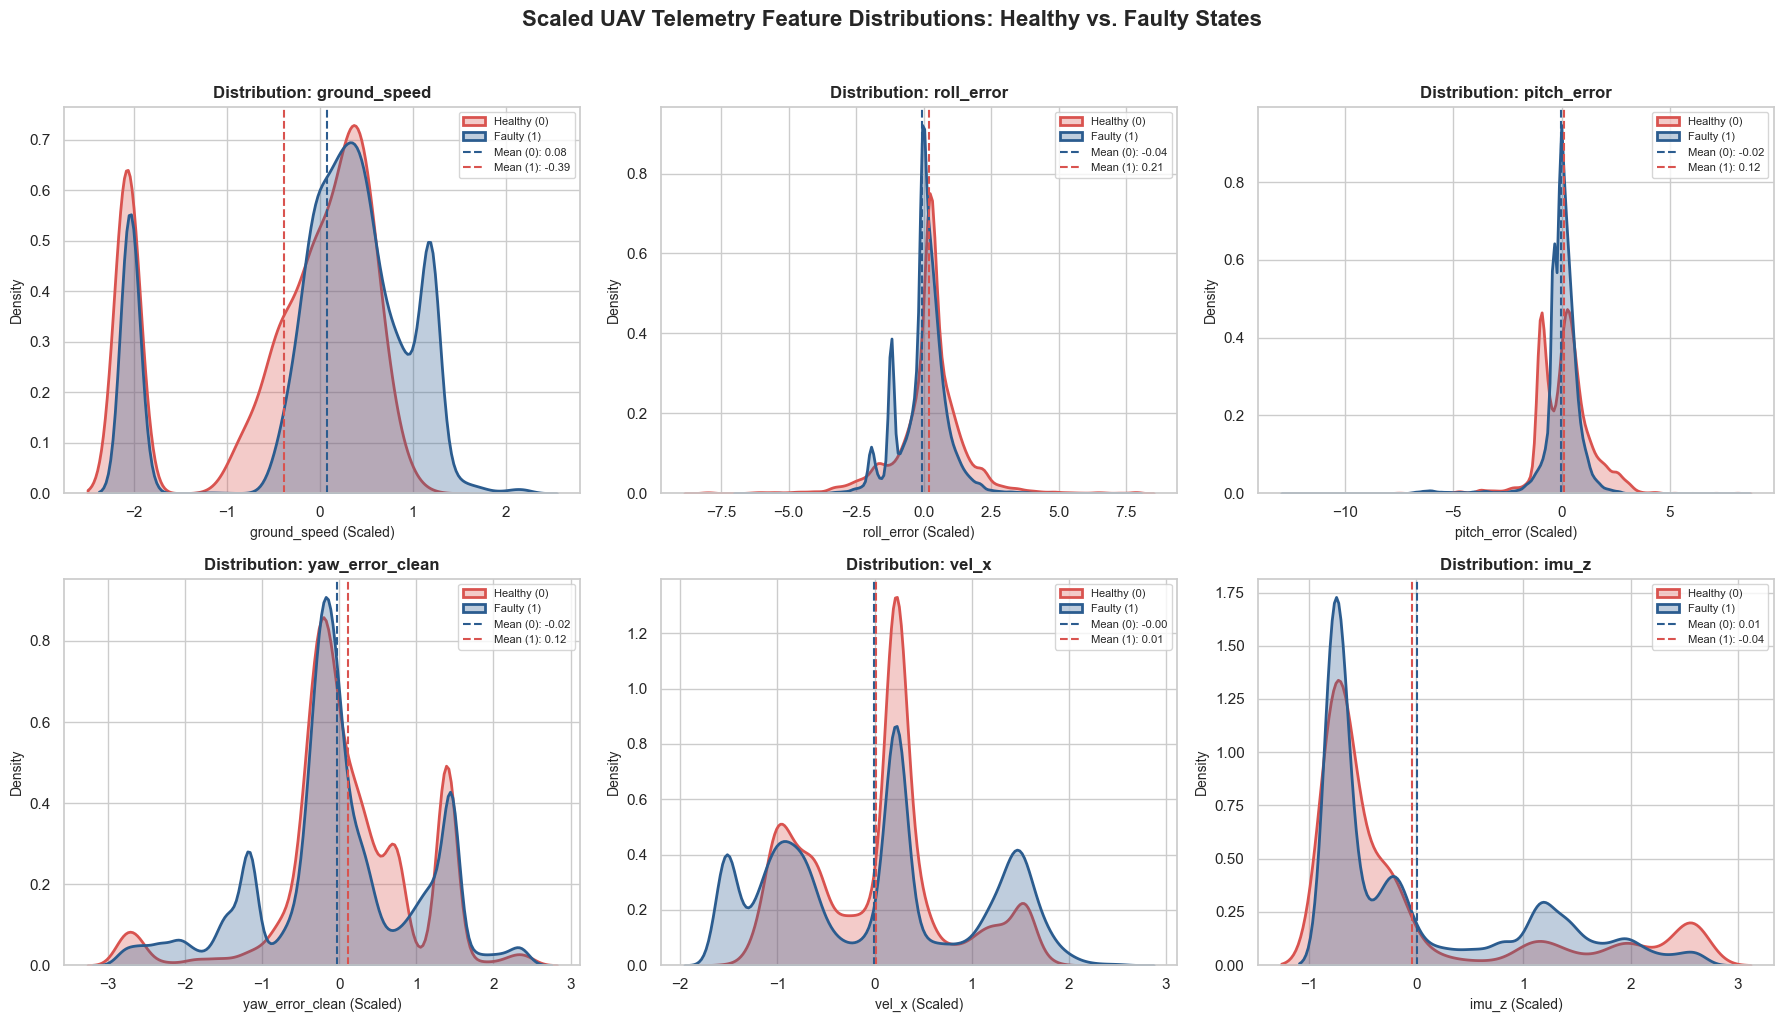

In [55]:
plot_df = df_train_scaled.copy()
plot_df['binary_fault'] = y_fault_train.values  # Uses the matching train split target

# Set visual style
sns.set_theme(style="whitegrid")

# Select core features to inspect distribution shifts
plot_features = [
    'ground_speed', 
    'roll_error', 
    'pitch_error', 
    'yaw_error_clean',
    'vel_x', 
    'imu_z'
]

# Create subplots grid
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, feature in enumerate(plot_features):
    ax = axes[idx]
    
    # Kernel Density Estimation (KDE) plot grouped by binary_fault
    sns.kdeplot(
        data=plot_df,
        x=feature,
        hue='binary_fault',
        common_norm=False,
        palette={0: '#2b5c8f', 1: '#d9534f'},
        fill=True,
        alpha=0.3,
        linewidth=2,
        ax=ax
    )
    
    # Calculate means per class for reference lines
    mean_0 = plot_df[plot_df['binary_fault'] == 0][feature].mean()
    mean_1 = plot_df[plot_df['binary_fault'] == 1][feature].mean()
    
    ax.axvline(mean_0, color='#2b5c8f', linestyle='--', linewidth=1.5, label=f'Healthy Mean: {mean_0:.2f}')
    ax.axvline(mean_1, color='#d9534f', linestyle='--', linewidth=1.5, label=f'Faulty Mean: {mean_1:.2f}')
    
    ax.set_title(f'Distribution: {feature}', fontsize=12, fontweight='bold')
    ax.set_xlabel(f'{feature} (Scaled)', fontsize=10)
    ax.set_ylabel('Density', fontsize=10)
    ax.legend(['Healthy (0)', 'Faulty (1)', f'Mean (0): {mean_0:.2f}', f'Mean (1): {mean_1:.2f}'], fontsize=8)

plt.suptitle('Scaled UAV Telemetry Feature Distributions: Healthy vs. Faulty States', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

StandardScaler transforms your raw telemetry values into standard deviation units ($z$-scores) so all features share a common scale, centered at a mean of $0$.
What Changed: yaw_error_clean (originally spanning $\pm 200$) and imu_z (spanning $\pm 1$) are now both scaled roughly between $-3$ and $+3$.Why It Matters: Distance- and gradient-based models (k-NN, SVM, Neural Networks) can now weight all 6 telemetry features equally without large-value features dominating the calculations.Data Shape: The underlying distribution shapes, peaks, and class separations between Healthy and Faulty states remain identical.

### Future Modeling Approaches

1. **Baseline – XGBoost**
   Establish a simple benchmark for predicting fault-related behavior using sensor and control features.

2. **Anomaly Detection**
   Learn normal UAV behavior and detect abnormal patterns that may appear before `fault_onset`.

3. **Liquid Neural Network (LNN)**
   Use time-series sequences to learn temporal UAV behavior and predict faults before they occur.

**Goal:** Compare the three approaches to determine whether modeling temporal behavior improves early fault prediction.


In [56]:
pos_weight = (y_fault_train == 0).sum() / (y_fault_train == 1).sum()
print(f"Calculated scale_pos_weight: {pos_weight:.2f}")

# 2. Initialize XGBoost Classifier
model = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    scale_pos_weight=pos_weight,
    eval_metric='aucpr',
    early_stopping_rounds=50,
    random_state=42,
    n_jobs=-1
)

# 3. Fit model on training split with validation monitoring
model.fit(
    df_train_scaled, y_fault_train,
    eval_set=[(df_val_scaled, y_fault_val)],
    verbose=50  # Print progress every 50 trees
)

# 4. Predict probabilities on validation set
val_probs = model.predict_proba(df_val_scaled)[:, 1]

# 5. Apply safety-critical decision threshold (0.30 for high recall)
val_preds = (val_probs >= 0.30).astype(int)

# 6. Print Performance Metrics
precision, recall, _ = precision_recall_curve(y_fault_val, val_probs)
pr_auc_score = auc(recall, precision)

print(f"\n---> Validation PR-AUC: {pr_auc_score:.4f}\n")
print(classification_report(y_fault_val, val_preds, target_names=['Healthy (0)', 'Faulty (1)']))

Calculated scale_pos_weight: 5.10
[0]	validation_0-aucpr:0.32585
[50]	validation_0-aucpr:0.46128
[100]	validation_0-aucpr:0.46223
[105]	validation_0-aucpr:0.46598

---> Validation PR-AUC: 0.4772

              precision    recall  f1-score   support

 Healthy (0)       0.98      0.55      0.71     23890
  Faulty (1)       0.16      0.90      0.27      2220

    accuracy                           0.58     26110
   macro avg       0.57      0.73      0.49     26110
weighted avg       0.91      0.58      0.67     26110



In [57]:
pos_weight = (y_fault_train == 0).sum() / (y_fault_train == 1).sum()

# 2. Train with proper learning rate & early stopping
model_2 = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.05,        # Raised from 0.005 to reach convergence
    max_depth=6,
    scale_pos_weight=pos_weight,
    eval_metric='aucpr',
    early_stopping_rounds=50,   # Stops when validation PR-AUC peaks
    random_state=42,
    n_jobs=-1
)

model_2.fit(
    df_train_scaled, y_fault_train,
    eval_set=[(df_val_scaled, y_fault_val)],
    verbose=100
)

# 3. Get raw validation probabilities
val_probs_raw = model_2.predict_proba(df_val_scaled)[:, 1]

# 4. Temporal Probability Smoothing (removes single-frame noise per flight)
val_df = pd.DataFrame({
    'flight_id': flight_id_val.values,
    'raw_probs': val_probs_raw
})

# 10-frame rolling window mean per flight
val_probs_smooth = val_df.groupby('flight_id')['raw_probs'].transform(
    lambda x: x.rolling(window=10, min_periods=1).mean()
).values

# 5. Threshold Search targeting F2-Score (Recall-focused, balanced precision)
best_thresh = 0.5
best_f2 = 0.0

for t in np.linspace(0.10, 0.90, 81): # Searching higher thresholds due to scale_pos_weight
    preds = (val_probs_smooth >= t).astype(int)
    score = fbeta_score(y_fault_val, preds, beta=2.0, zero_division=0)
    if score > best_f2:
        best_f2 = score
        best_thresh = t

# 6. Final Evaluation
final_preds = (val_probs_smooth >= best_thresh).astype(int)
p, r, _ = precision_recall_curve(y_fault_val, val_probs_smooth)

print(f"\n---> Optimal Threshold: {best_thresh:.2f}")
print(f"---> Smoothed Validation PR-AUC: {auc(r, p):.4f}")
print(f"---> Best F2-Score: {best_f2:.4f}\n")
print(classification_report(y_fault_val, final_preds, target_names=['Healthy (0)', 'Faulty (1)']))

[0]	validation_0-aucpr:0.32585


[100]	validation_0-aucpr:0.46223
[106]	validation_0-aucpr:0.46384

---> Optimal Threshold: 0.56
---> Smoothed Validation PR-AUC: 0.4778
---> Best F2-Score: 0.5197

              precision    recall  f1-score   support

 Healthy (0)       0.96      0.87      0.91     23890
  Faulty (1)       0.31      0.63      0.41      2220

    accuracy                           0.85     26110
   macro avg       0.63      0.75      0.66     26110
weighted avg       0.91      0.85      0.87     26110

